# CBESD English Audio Emotion / Stress

## What this notebook includes
- environment setup
- Kaggle download cell
- extraction
- English-only filtering
- transcript merge logic
- preprocessing
- thesis-ready visualizations
- training and testing with:
  - CNN on mel-spectrograms
  - BiLSTM on MFCC sequences
- confusion matrix
- ROC-AUC
- training curves
- model comparison chart

In [1]:
# =========================
# 1. ENVIRONMENT SETUP
# =========================
# Run this once, then restart kernel before running the rest.

!pip uninstall -y librosa soxr datasets pyarrow sentencepiece || true
!pip install --upgrade pip setuptools wheel
!pip install --no-cache-dir "numpy==1.26.4" "scipy==1.13.1" pandas scikit-learn matplotlib tqdm kaggle openpyxl
!pip install --no-cache-dir "soundfile==0.12.1"
!pip install --no-cache-dir torch torchaudio transformers accelerate
!sudo yum install -y libsndfile

Found existing installation: pyarrow 20.0.0
Uninstalling pyarrow-20.0.0:
  Successfully uninstalled pyarrow-20.0.0
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.10.2
    Uninstalling setuptools-80.10.2:
      Successfully uninstalled setuptools-80.10.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab 4.5.3 requires httpx<1,>=0.25.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 277.6 MB/s  0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [scipy]
      Successfully uninstalled scipy-1.15.2━━━━━━━━━━━━━━━━━━━ 1/6 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# =========================
# 2. IMPORTS
# =========================
import os
import math
import json
import zipfile
import random
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

import soundfile as sf
from scipy.signal import resample_poly

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio

from transformers import Wav2Vec2Model

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


DEVICE: cpu


In [3]:
# =========================
# 3. PROJECT PATHS
# =========================
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "cbesd_project"
RAW_DIR = DATA_DIR / "raw"
EXT_DIR = DATA_DIR / "extracted"
FIG_DIR = DATA_DIR / "figures"
CKPT_DIR = DATA_DIR / "checkpoints"
OUT_DIR = DATA_DIR / "outputs"

for d in [RAW_DIR, EXT_DIR, FIG_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /home/ec2-user/SageMaker
DATA_DIR: /home/ec2-user/SageMaker/cbesd_project


In [4]:
from pathlib import Path
import os
import json

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)

# move uploaded file to ~/.kaggle/kaggle.json
# adjust the source path if your file is elsewhere
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

with open(Path.home() / ".kaggle" / "kaggle.json", "r") as f:
    creds = json.load(f)

print("Kaggle configured for user:", creds.get("username"))

Kaggle configured for user: sanghamitrapanda


In [5]:
import os
from pathlib import Path

print("RAW_DIR:", RAW_DIR)
print("Free disk space:")
!df -h

print("\nCurrent raw folder size:")
!du -sh {RAW_DIR} 2>/dev/null || true

RAW_DIR: /home/ec2-user/SageMaker/cbesd_project/raw
Free disk space:
Filesystem      Size  Used Avail Use% Mounted on
devtmpfs        1.9G     0  1.9G   0% /dev
tmpfs           1.9G     0  1.9G   0% /dev/shm
tmpfs           1.9G  600K  1.9G   1% /run
tmpfs           1.9G     0  1.9G   0% /sys/fs/cgroup
/dev/nvme0n1p1  135G   83G   53G  62% /
/dev/nvme1n1    4.8G  3.6G  966M  80% /home/ec2-user/SageMaker
tmpfs           387M     0  387M   0% /run/user/1000
tmpfs           387M     0  387M   0% /run/user/1002
tmpfs           387M     0  387M   0% /run/user/1001

Current raw folder size:
996M	/home/ec2-user/SageMaker/cbesd_project/raw


In [6]:
# =========================
# 4. KAGGLE DOWNLOAD HELPERS
# =========================
# Replace with your exact Kaggle slug for CBESD / BESD
CBESD_KAGGLE_DATASET = "pranuthi19/bilingual-emotion-speech-datasetbesd"

def run_cmd(cmd):
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result

def download_kaggle_dataset(dataset_slug, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    result = run_cmd([
        "kaggle", "datasets", "download",
        "-d", dataset_slug,
        "-p", str(out_dir),
        "--force",
        "--quiet"
    ])

    if result.returncode != 0:
        raise RuntimeError(
            f"Kaggle download failed with code {result.returncode}. "
            f"Check disk space, memory, and whether a partial zip exists in {out_dir}."
        )
def unzip_all(zip_dir, extract_dir):
    extract_dir.mkdir(parents=True, exist_ok=True)
    for zf in zip_dir.glob("*.zip"):
        target = extract_dir / zf.stem
        target.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zf, "r") as z:
            z.extractall(target)
        print("Extracted:", zf.name, "->", target)

# Uncomment after Kaggle auth is configured and slug is updated
#download_kaggle_dataset(CBESD_KAGGLE_DATASET, RAW_DIR)
#unzip_all(RAW_DIR, EXT_DIR)

In [7]:
def print_tree(root: Path, max_depth=4, max_items=100):
    count = 0
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth <= max_depth:
            print("  " * depth + path.name)
            count += 1
            if count >= max_items:
                print("...truncated...")
                break

print_tree(EXT_DIR)

  bilingual-emotion-speech-datasetbesd
    BESD
      ENGLISH
        ANGER
        DISGUST
        FEAR
        HAPPY
        NEUTRAL
        SAD
      TELUGU
        ANGER
        DISGUST
        FEAR
        HAPPY
        NEUTRAL
        SAD


In [8]:
# =========================
# 6. LOAD ENGLISH-ONLY CBESD METADATA
# =========================
KNOWN_LABELS = [
    "happy", "sad", "angry", "fearful", "neutral",
    "stress", "non_stress", "surprised", "disgust"
]

def infer_language_from_path(path: Path):
    tokens = [path.stem.lower()] + [p.name.lower() for p in path.parents]
    for t in tokens:
        if "english" in t or t == "en":
            return "english"
        if "hindi" in t or t == "hi":
            return "hindi"
        if "bengali" in t or t == "bn":
            return "bengali"
    return None

def infer_label_from_path(path: Path):
    tokens = [path.stem.lower()] + [p.name.lower() for p in path.parents]
    for t in tokens:
        for lab in KNOWN_LABELS:
            if lab in t:
                return lab
    return None

def audio_duration(path):
    try:
        info = sf.info(str(path))
        return info.frames / info.samplerate
    except Exception:
        return np.nan

def load_table(path: Path):
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".tsv":
        return pd.read_csv(path, sep="\t")
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    return pd.DataFrame()

def merge_transcripts(df, root):
    files = list(root.rglob("*.csv")) + list(root.rglob("*.tsv")) + list(root.rglob("*.xlsx")) + list(root.rglob("*.xls"))
    for fp in files:
        try:
            tdf = load_table(fp)
            if tdf.empty:
                continue
            tdf.columns = [c.strip().lower() for c in tdf.columns]
            file_col = next((c for c in ["file_name", "filename", "file", "audio_file", "wav_file"] if c in tdf.columns), None)
            text_col = next((c for c in ["text", "transcript", "utterance", "sentence"] if c in tdf.columns), None)
            if file_col and text_col:
                temp = tdf[[file_col, text_col]].copy()
                temp.columns = ["file_name", "text"]
                temp["file_name"] = temp["file_name"].astype(str)
                df = df.merge(temp, on="file_name", how="left", suffixes=("", "_y"))
                if "text_y" in df.columns:
                    df["text"] = df["text_y"].fillna(df["text"])
                    df = df.drop(columns=["text_y"])
        except Exception as e:
            print("Skipping transcript merge for", fp.name, "|", e)
    return df

def load_cbesd(root: Path):
    rows = []
    wavs = list(root.rglob("*.wav"))
    for fp in wavs:
        lang = infer_language_from_path(fp)
        if lang != "english":
            continue
        label = infer_label_from_path(fp)
        if label is None:
            continue
        rows.append({
            "audio_path": str(fp),
            "file_name": fp.name,
            "label": label,
            "language": lang,
            "duration_sec": audio_duration(fp),
            "text": ""
        })

    df = pd.DataFrame(rows)
    if len(df):
        df = merge_transcripts(df, root)
    return df

df = load_cbesd(EXT_DIR)
print("Shape:", df.shape)
df.head()

Shape: (1754, 6)


,audio_path,file_name,label,language,duration_sec,text
0,/home/ec2-user/SageMaker/cbesd_project/extract...,43.EF_6 Angry_1.wav,angry,english,2.304000,
1,/home/ec2-user/SageMaker/cbesd_project/extract...,38.EM_10 Angry_3.wav,angry,english,2.304000,
2,/home/ec2-user/SageMaker/cbesd_project/extract...,45.EF_8 Angry_3.wav,angry,english,1.792000,
3,/home/ec2-user/SageMaker/cbesd_project/extract...,53.EM_6 Angry_2.wav,angry,english,2.645333,
4,/home/ec2-user/SageMaker/cbesd_project/extract...,65.EM_9 Angry_3.wav,angry,english,2.560000,


## Thesis Visualizations: Dataset Understanding

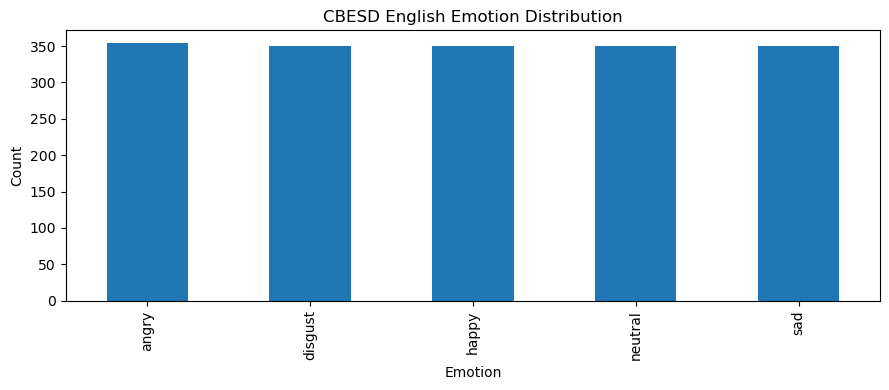

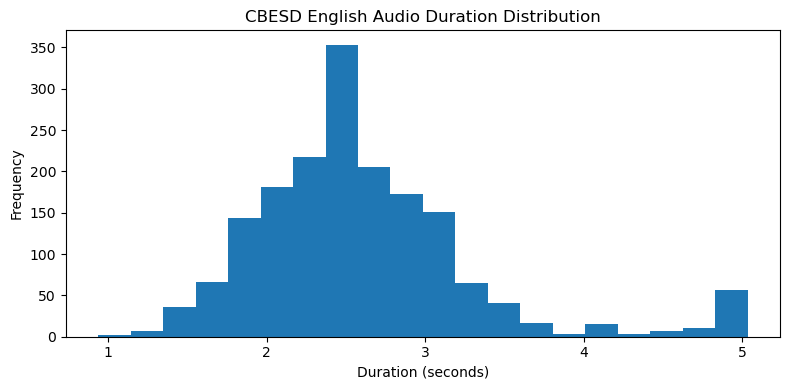

In [9]:
# =========================
# 7. EDA VISUALIZATIONS
# =========================
if len(df):
    plt.figure(figsize=(9, 4))
    df["label"].value_counts().sort_index().plot(kind="bar")
    plt.title("CBESD English Emotion Distribution")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_emotion_distribution.png", dpi=220)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df["duration_sec"].dropna(), bins=20)
    plt.title("CBESD English Audio Duration Distribution")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_duration_distribution.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")

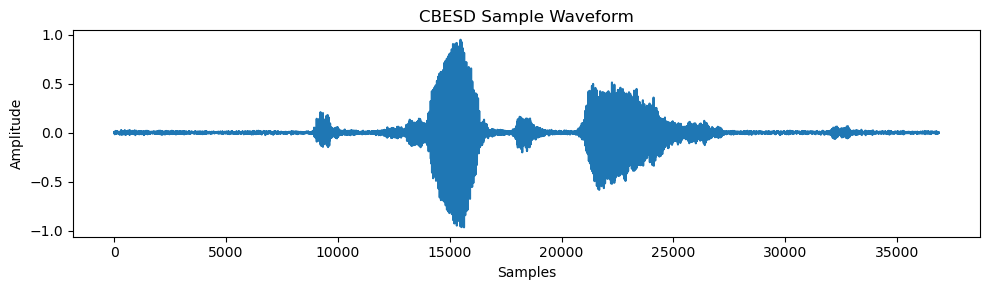

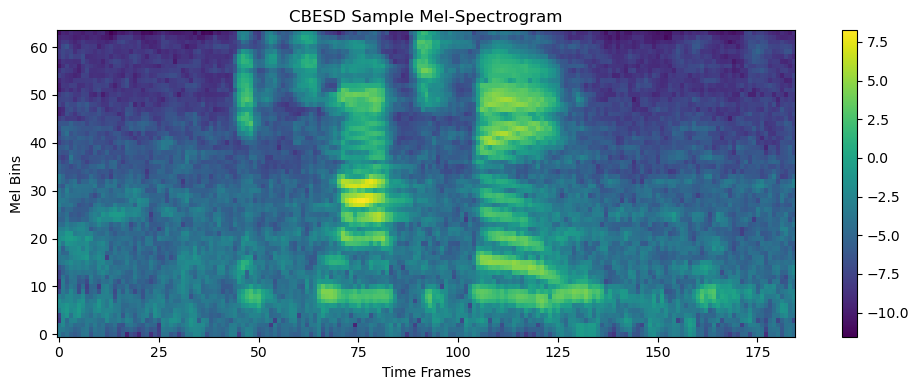

In [10]:
# =========================
# 8. SAMPLE WAVEFORM AND MEL-SPECTROGRAM
# =========================
MEL_EXTRACTOR_VIS = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=64
)

def safe_read_audio(path):
    y, sr = sf.read(str(path))
    if len(y.shape) > 1:
        y = np.mean(y, axis=1)
    return y.astype(np.float32), sr

def safe_resample(y, orig_sr, target_sr=16000):
    if orig_sr == target_sr:
        return y.astype(np.float32)
    g = math.gcd(orig_sr, target_sr)
    up = target_sr // g
    down = orig_sr // g
    return resample_poly(y, up, down).astype(np.float32)

if len(df):
    sample_path = Path(df.iloc[0]["audio_path"])
    y, sr = safe_read_audio(sample_path)
    y16 = safe_resample(y, sr, 16000)

    mel = MEL_EXTRACTOR_VIS(torch.tensor(y16)).numpy()
    mel = np.log(mel + 1e-9)

    plt.figure(figsize=(10, 3))
    plt.plot(y16)
    plt.title("CBESD Sample Waveform")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_sample_waveform.png", dpi=220)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.imshow(mel, aspect="auto", origin="lower")
    plt.title("CBESD Sample Mel-Spectrogram")
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Bins")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_sample_melspectrogram.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")

## Added Thesis-Aligned Visualisations

This section adds the missing thesis/proposal visuals for:
- stress vs non-stress analysis
- chi-square style bivariate analysis
- split composition and missing-value review
- lightweight acoustic stress-marker plots
- transcript-length analysis when text is available


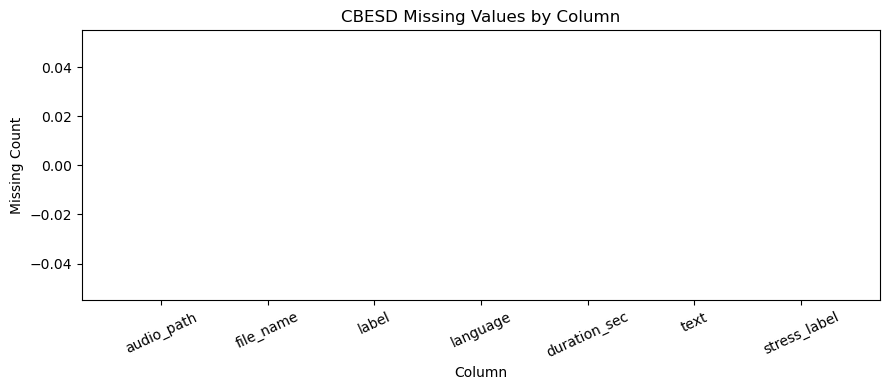

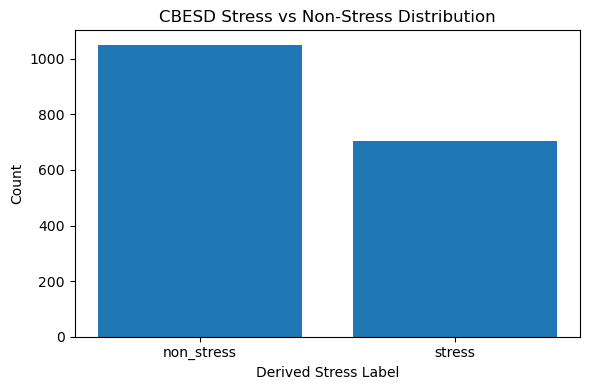

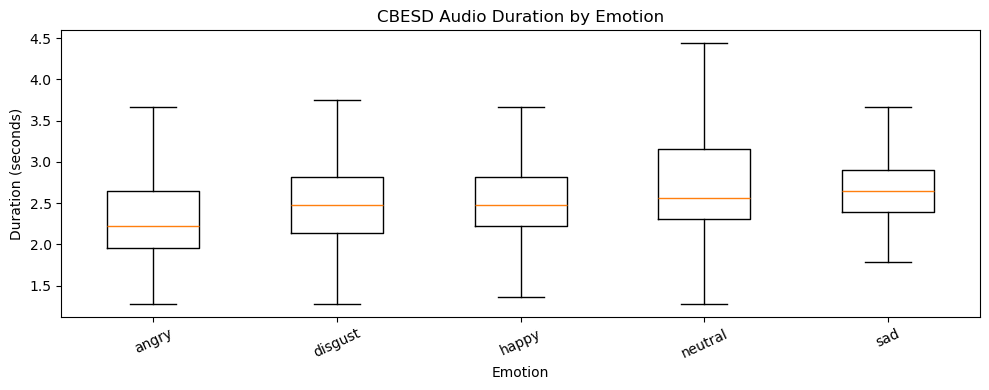

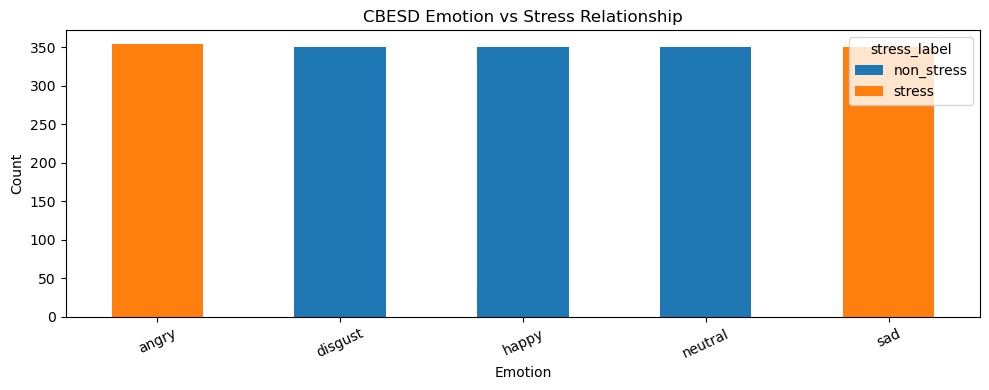

{'chi2': 1754.0, 'p_value': 0.0, 'dof': 4}


In [11]:

# =========================
# 7B. EDA / STRESS ANALYSIS
# =========================
def derive_stress_label(label_value):
    label_value = str(label_value).strip().lower()
    if label_value in {"stress", "stressed", "fearful", "angry", "sad"}:
        return "stress"
    if label_value in {"non_stress", "non-stress", "neutral", "happy", "calm", "surprised"}:
        return "non_stress"
    return "stress" if "stress" in label_value else "non_stress"

if len(df):
    df["stress_label"] = df["label"].map(derive_stress_label)

    # Missing values
    missing_counts = df.isna().sum().sort_values(ascending=False)
    plt.figure(figsize=(9, 4))
    plt.bar(missing_counts.index.astype(str), missing_counts.values)
    plt.title("CBESD Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_missing_values.png", dpi=220)
    plt.show()

    # Stress vs non-stress distribution
    stress_counts = df["stress_label"].value_counts()
    plt.figure(figsize=(6, 4))
    plt.bar(stress_counts.index, stress_counts.values)
    plt.title("CBESD Stress vs Non-Stress Distribution")
    plt.xlabel("Derived Stress Label")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_stress_distribution.png", dpi=220)
    plt.show()

    # Duration by label
    duration_by_label = [df.loc[df["label"] == lab, "duration_sec"].dropna().values for lab in sorted(df["label"].unique())]
    plt.figure(figsize=(10, 4))
    plt.boxplot(duration_by_label, labels=sorted(df["label"].unique()), showfliers=False)
    plt.title("CBESD Audio Duration by Emotion")
    plt.xlabel("Emotion")
    plt.ylabel("Duration (seconds)")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_duration_by_emotion_boxplot.png", dpi=220)
    plt.show()

    # Bivariate relation: emotion vs stress
    emotion_stress = pd.crosstab(df["label"], df["stress_label"])
    emotion_stress.plot(kind="bar", stacked=True, figsize=(10, 4))
    plt.title("CBESD Emotion vs Stress Relationship")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_emotion_vs_stress.png", dpi=220)
    plt.show()

    try:
        from scipy.stats import chi2_contingency
        chi2, p_value, dof, expected = chi2_contingency(emotion_stress)
        print({"chi2": float(chi2), "p_value": float(p_value), "dof": int(dof)})
    except Exception as e:
        print("Chi-square test skipped:", e)

    # Text-length analysis if transcripts are present
    if "text" in df.columns and df["text"].fillna("").str.strip().ne("").any():
        df["text_len"] = df["text"].fillna("").astype(str).str.split().map(len)
        plt.figure(figsize=(8, 4))
        plt.hist(df["text_len"], bins=25)
        plt.title("CBESD Transcript Length Distribution")
        plt.xlabel("Number of Words")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "cbesd_text_length_distribution.png", dpi=220)
        plt.show()

        grouped = [df.loc[df["stress_label"] == g, "text_len"].dropna().values for g in ["stress", "non_stress"] if g in set(df["stress_label"])]
        labels = [g for g in ["stress", "non_stress"] if g in set(df["stress_label"])]
        if grouped:
            plt.figure(figsize=(6, 4))
            plt.boxplot(grouped, labels=labels, showfliers=False)
            plt.title("CBESD Transcript Length by Stress Label")
            plt.xlabel("Stress Label")
            plt.ylabel("Number of Words")
            plt.tight_layout()
            plt.savefig(FIG_DIR / "cbesd_text_length_by_stress.png", dpi=220)
            plt.show()
else:
    print("Dataframe is empty.")


In [12]:
# =========================
# 9. LABEL ENCODING AND SPLITS
# =========================
if len(df):
    label_encoder = LabelEncoder()
    df["label_id"] = label_encoder.fit_transform(df["label"])

    train_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=SEED,
        stratify=df["label"],
    )

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.1765,
        random_state=SEED,
        stratify=train_df["label"],
    )

    print("Train:", len(train_df))
    print("Val  :", len(val_df))
    print("Test :", len(test_df))
    print("Classes:", list(label_encoder.classes_))
else:
    label_encoder = LabelEncoder()
    train_df = val_df = test_df = pd.DataFrame()

Train: 1227
Val  : 263
Test : 264
Classes: ['angry', 'disgust', 'happy', 'neutral', 'sad']


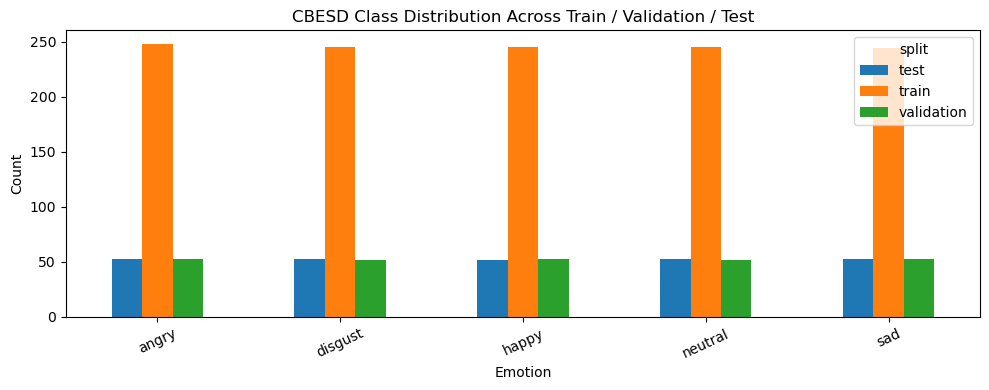

In [13]:

# =========================
# 10B. SPLIT DISTRIBUTION VISUAL
# =========================
if len(train_df):
    train_df["split"] = "train"
    val_df["split"] = "validation"
    test_df["split"] = "test"

    split_plot_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    split_pivot = pd.crosstab(split_plot_df["label"], split_plot_df["split"])
    split_pivot.plot(kind="bar", figsize=(10, 4))
    plt.title("CBESD Class Distribution Across Train / Validation / Test")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_split_distribution.png", dpi=220)
    plt.show()
else:
    print("Split data unavailable.")


CBESD lightweight audio features: 100%|██████████| 300/300 [00:03<00:00, 78.99it/s]


,label,stress_label,duration_sec,rms_energy,zcr,spectral_centroid
0,angry,stress,2.304000,0.106777,0.180533,2732.497959
1,angry,stress,2.304000,0.157697,0.086103,1185.005131
2,angry,stress,1.792000,0.134617,0.107007,1582.564720
3,angry,stress,2.645333,0.103337,0.157566,2236.590669
4,angry,stress,2.560000,0.090239,0.094411,1203.900417


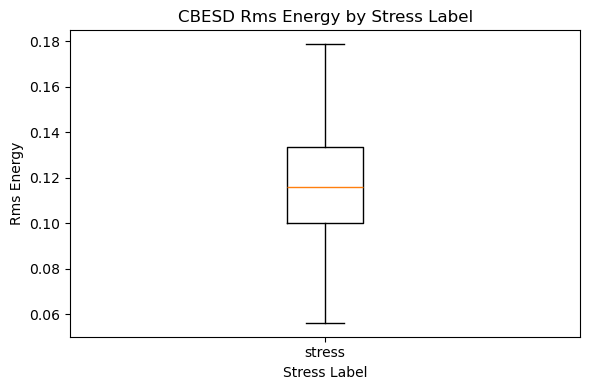

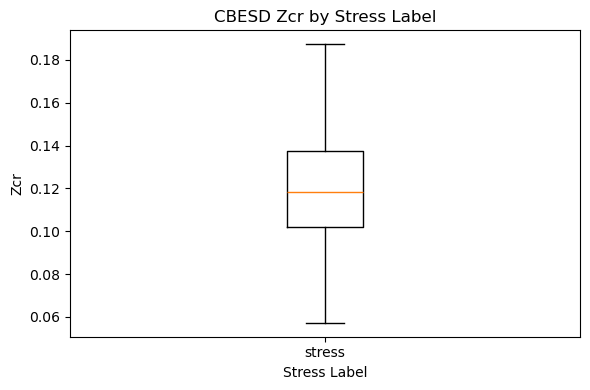

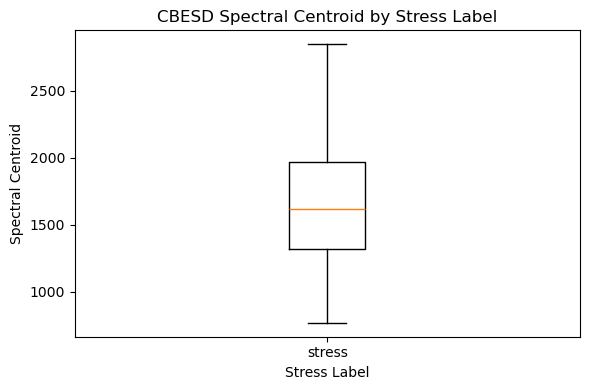

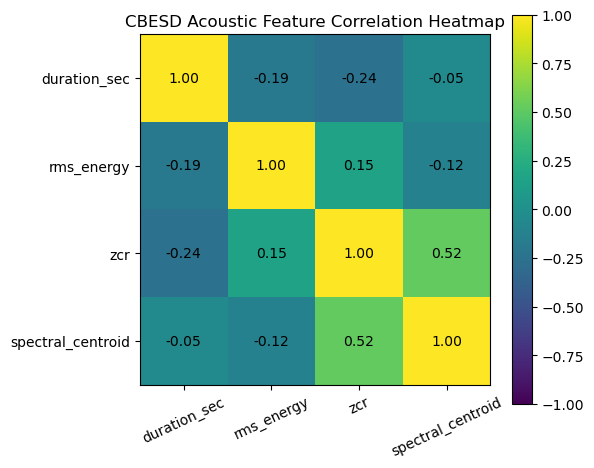

In [14]:

# =========================
# 10C. LIGHTWEIGHT ACOUSTIC STRESS MARKER VISUALS
# =========================
def compute_lightweight_audio_features(frame, sample_limit=300):
    rows = []
    work = frame.head(sample_limit).copy()
    for _, row in tqdm(work.iterrows(), total=len(work), desc="CBESD lightweight audio features"):
        try:
            y, sr = safe_read_audio(Path(row["audio_path"]))
            y = safe_resample(y, sr, 16000)
            if np.max(np.abs(y)) > 0:
                y = y / np.max(np.abs(y))
            spec = np.abs(np.fft.rfft(y))
            freqs = np.fft.rfftfreq(len(y), d=1/16000)
            centroid = float((freqs * spec).sum() / (spec.sum() + 1e-9))
            rows.append({
                "label": row["label"],
                "stress_label": derive_stress_label(row["label"]),
                "duration_sec": float(row.get("duration_sec", np.nan)),
                "rms_energy": float(np.sqrt(np.mean(y**2))),
                "zcr": float(np.mean(np.abs(np.diff(np.signbit(y).astype(np.int8))))),
                "spectral_centroid": centroid,
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

if len(df):
    acoustic_df = compute_lightweight_audio_features(df)
    display(acoustic_df.head())

    for feat in ["rms_energy", "zcr", "spectral_centroid"]:
        grouped = [acoustic_df.loc[acoustic_df["stress_label"] == lab, feat].dropna().values for lab in ["stress", "non_stress"] if lab in set(acoustic_df["stress_label"])]
        labels = [lab for lab in ["stress", "non_stress"] if lab in set(acoustic_df["stress_label"])]
        if grouped:
            plt.figure(figsize=(6, 4))
            plt.boxplot(grouped, labels=labels, showfliers=False)
            plt.title(f"CBESD {feat.replace('_', ' ').title()} by Stress Label")
            plt.xlabel("Stress Label")
            plt.ylabel(feat.replace("_", " ").title())
            plt.tight_layout()
            plt.savefig(FIG_DIR / f"cbesd_{feat}_by_stress.png", dpi=220)
            plt.show()

    feature_cols = ["duration_sec", "rms_energy", "zcr", "spectral_centroid"]
    corr = acoustic_df[feature_cols].corr(numeric_only=True)
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, vmin=-1, vmax=1)
    plt.xticks(range(len(feature_cols)), feature_cols, rotation=25)
    plt.yticks(range(len(feature_cols)), feature_cols)
    for i in range(len(feature_cols)):
        for j in range(len(feature_cols)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
    plt.title("CBESD Acoustic Feature Correlation Heatmap")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_acoustic_feature_correlation.png", dpi=220)
    plt.show()
else:
    print("No audio rows available.")


In [15]:
# =========================
# 10. AUDIO LOADER
# =========================
MAX_SEC = 4
SR = 16000
N_MELS = 64
N_MFCC = 40
BATCH_SIZE = 16
EPOCHS = 8

MEL_EXTRACTOR = torchaudio.transforms.MelSpectrogram(sample_rate=SR, n_mels=N_MELS)
MFCC_EXTRACTOR = torchaudio.transforms.MFCC(sample_rate=SR, n_mfcc=N_MFCC)

def load_fixed_audio(path, sr=SR, max_sec=MAX_SEC):
    y, orig_sr = safe_read_audio(path)
    y = safe_resample(y, orig_sr, sr)

    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    target_len = sr * max_sec
    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))

    return y.astype(np.float32)

In [16]:
# =========================
# 11. DATASET CLASS
# =========================
class CBESDDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, mode="mel"):
        self.frame = frame.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y = load_fixed_audio(row["audio_path"])
        y_t = torch.tensor(y, dtype=torch.float32)
        label = int(row["label_id"])

        if self.mode == "mel":
            feat = MEL_EXTRACTOR(y_t)
            feat = torch.log(feat + 1e-9).unsqueeze(0) if feat.ndim == 2 else torch.log(feat + 1e-9)
        elif self.mode == "mfcc":
            feat = MFCC_EXTRACTOR(y_t).transpose(0, 1)
        else:
            feat = y_t

        return feat, torch.tensor(label, dtype=torch.long)

In [17]:
# =========================
# 12. MODELS
# =========================
class CNNMelNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class BiLSTMMFCCNet(nn.Module):
    def __init__(self, n_classes, input_dim=N_MFCC, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

class FastWav2VecClassifier(nn.Module):
    def __init__(self, n_classes, unfreeze_last_block=True):
        super().__init__()
        self.encoder = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        hidden = self.encoder.config.hidden_size

        for param in self.encoder.parameters():
            param.requires_grad = False

        if unfreeze_last_block and hasattr(self.encoder, "encoder"):
            for param in self.encoder.encoder.layers[-1].parameters():
                param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, input_values):
        out = self.encoder(input_values=input_values)
        pooled = out.last_hidden_state.mean(dim=1)
        return self.classifier(pooled)

In [18]:
# =========================
# 13. DATALOADERS
# =========================
def make_loaders(mode):
    train_ds = CBESDDataset(train_df, mode=mode)
    val_ds = CBESDDataset(val_df, mode=mode)
    test_ds = CBESDDataset(test_df, mode=mode)

    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    )

In [19]:
# =========================
# 14. TRAINING AND EVALUATION HELPERS
# =========================
def train_model(model, train_loader, val_loader, ckpt_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(EPOCHS):
        model.train()
        train_loss_total = 0.0
        train_preds = []
        train_true = []

        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * yb.size(0)
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_true.extend(yb.detach().cpu().numpy())

        train_loss = train_loss_total / len(train_loader.dataset)
        train_acc = accuracy_score(train_true, train_preds)

        model.eval()
        val_loss_total = 0.0
        val_preds = []
        val_true = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss_total += loss.item() * yb.size(0)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        val_loss = val_loss_total / len(val_loader.dataset)
        val_acc = accuracy_score(val_true, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), CKPT_DIR / ckpt_name)

        print(
            f"Epoch {epoch+1}: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

    return history

def evaluate_model(model, test_loader, model_name):
    model.eval()
    preds = []
    probs = []
    true = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)

            probs.extend(prob)
            preds.extend(pred)
            true.extend(yb.numpy())

    acc = accuracy_score(true, preds)
    p, r, f1, _ = precision_recall_fscore_support(
        true, preds, average="weighted", zero_division=0
    )

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
    plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=220)
    plt.show()

    y_true_bin = label_binarize(true, classes=list(range(len(label_encoder.classes_))))
    roc_auc = roc_auc_score(y_true_bin, np.array(probs), multi_class="ovr")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "roc_auc": roc_auc,
    }

def plot_history(history, title_prefix, file_prefix):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{file_prefix}_accuracy_curve.png", dpi=220)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{file_prefix}_loss_curve.png", dpi=220)
    plt.show()

Epoch 1/8: 100%|██████████| 77/77 [00:34<00:00,  2.21it/s]


Epoch 1: train_loss=1.5993, val_loss=1.5436, train_acc=0.2494, val_acc=0.2510


Epoch 2/8: 100%|██████████| 77/77 [00:25<00:00,  2.99it/s]


Epoch 2: train_loss=1.5473, val_loss=1.5231, train_acc=0.2926, val_acc=0.2852


Epoch 3/8: 100%|██████████| 77/77 [00:24<00:00,  3.17it/s]


...

Epoch 6: train_loss=1.3634, val_loss=1.4164, train_acc=0.4083, val_acc=0.3764


Epoch 7/8: 100%|██████████| 77/77 [00:24<00:00,  3.17it/s]


Epoch 7: train_loss=1.3362, val_loss=1.3726, train_acc=0.4173, val_acc=0.3688


Epoch 8/8: 100%|██████████| 77/77 [00:25<00:00,  2.98it/s]


Epoch 8: train_loss=1.2789, val_loss=1.3613, train_acc=0.4531, val_acc=0.4106


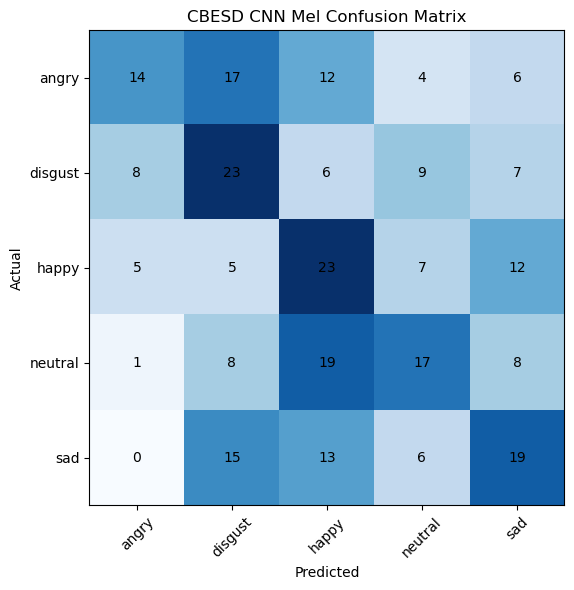

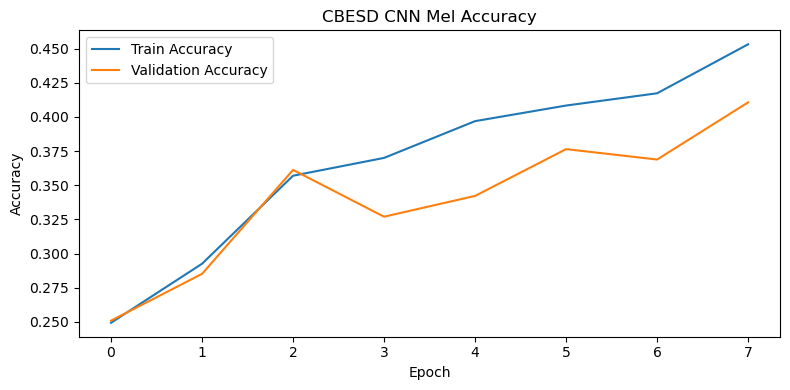

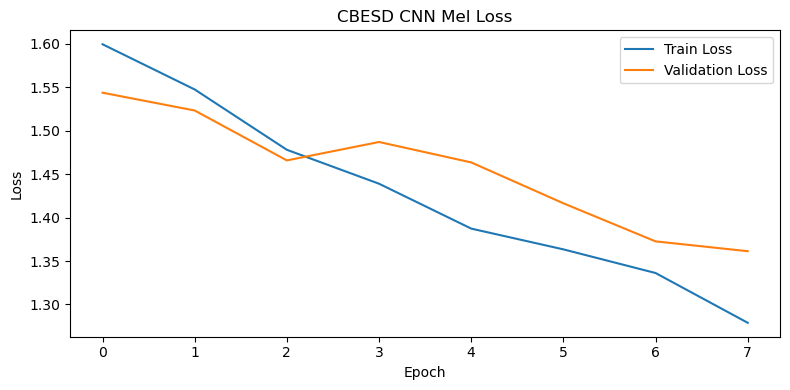

{'model': 'CBESD CNN Mel', 'accuracy': 0.36363636363636365, 'precision': 0.3830640349225324, 'recall': 0.36363636363636365, 'f1': 0.36196035492115614, 'roc_auc': 0.7280148783524444}


In [20]:
# =========================
# 15. TRAIN CNN ON MEL-SPECTROGRAMS
# =========================
if len(train_df):
    cnn_train_loader, cnn_val_loader, cnn_test_loader = make_loaders("mel")

    cnn_model = CNNMelNet(len(label_encoder.classes_)).to(DEVICE)
    cnn_history = train_model(cnn_model, cnn_train_loader, cnn_val_loader, "cbesd_cnn_mel.pt")

    cnn_model.load_state_dict(torch.load(CKPT_DIR / "cbesd_cnn_mel.pt", map_location=DEVICE))
    cnn_results = evaluate_model(cnn_model, cnn_test_loader, "CBESD CNN Mel")
    plot_history(cnn_history, "CBESD CNN Mel", "cbesd_cnn_mel")
    print(cnn_results)
else:
    print("Training data not available.")

Epoch 1/8: 100%|██████████| 77/77 [00:50<00:00,  1.53it/s]


Epoch 1: train_loss=1.6002, val_loss=1.5649, train_acc=0.2078, val_acc=0.2357


Epoch 2/8: 100%|██████████| 77/77 [00:51<00:00,  1.50it/s]


Epoch 2: train_loss=1.5540, val_loss=1.5409, train_acc=0.2461, val_acc=0.2966


Epoch 3/8: 100%|██████████| 77/77 [00:49<00:00,  1.55it/s]


...

Epoch 6: train_loss=1.3649, val_loss=1.3789, train_acc=0.3757, val_acc=0.4030


Epoch 7/8: 100%|██████████| 77/77 [00:49<00:00,  1.54it/s]


Epoch 7: train_loss=1.3253, val_loss=1.3416, train_acc=0.3993, val_acc=0.4068


Epoch 8/8: 100%|██████████| 77/77 [00:49<00:00,  1.56it/s]


Epoch 8: train_loss=1.2932, val_loss=1.3558, train_acc=0.4303, val_acc=0.3764


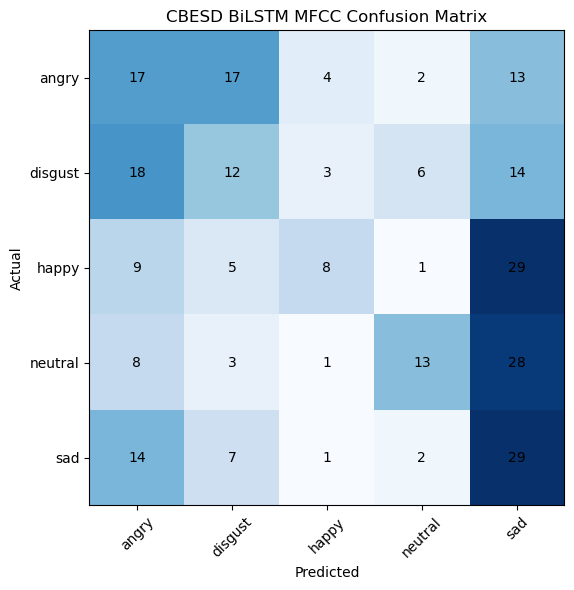

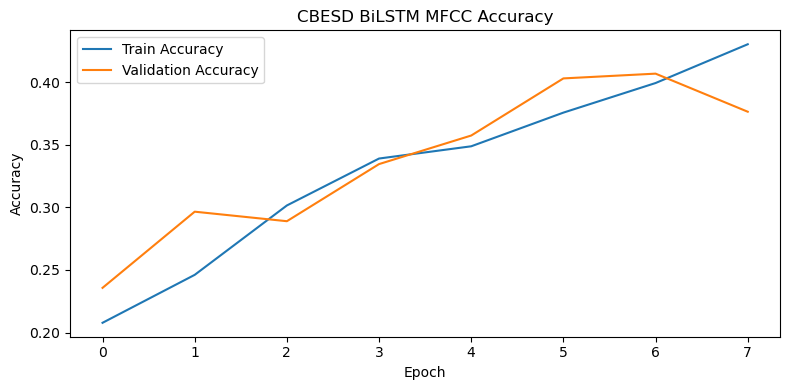

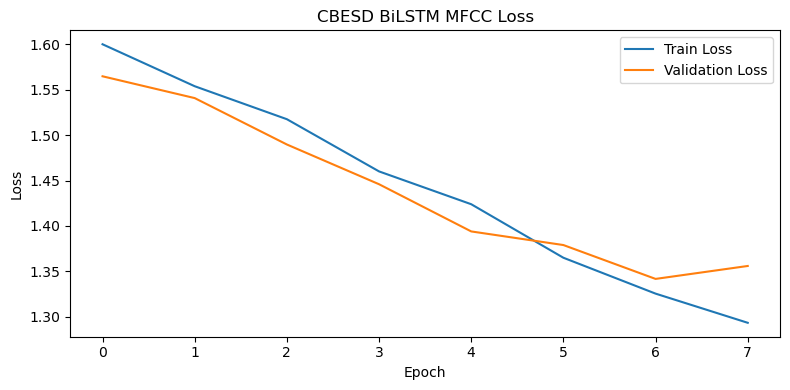

{'model': 'CBESD BiLSTM MFCC', 'accuracy': 0.29924242424242425, 'precision': 0.35941951547800177, 'recall': 0.29924242424242425, 'f1': 0.29063790304722004, 'roc_auc': 0.6977912903514263}


In [22]:
# =========================
# 16. TRAIN BILSTM ON MFCC SEQUENCES
# =========================
if len(train_df):
    lstm_train_loader, lstm_val_loader, lstm_test_loader = make_loaders("mfcc")

    lstm_model = BiLSTMMFCCNet(len(label_encoder.classes_)).to(DEVICE)
    lstm_history = train_model(lstm_model, lstm_train_loader, lstm_val_loader, "cbesd_bilstm_mfcc.pt")

    lstm_model.load_state_dict(torch.load(CKPT_DIR / "cbesd_bilstm_mfcc.pt", map_location=DEVICE))
    lstm_results = evaluate_model(lstm_model, lstm_test_loader, "CBESD BiLSTM MFCC")
    plot_history(lstm_history, "CBESD BiLSTM MFCC", "cbesd_bilstm_mfcc")
    print(lstm_results)
else:
    print("Training data not available.")

               model  accuracy  precision    recall        f1   roc_auc
0      CBESD CNN Mel  0.363636   0.383064  0.363636  0.361960  0.728015
1  CBESD BiLSTM MFCC  0.299242   0.359420  0.299242  0.290638  0.697791


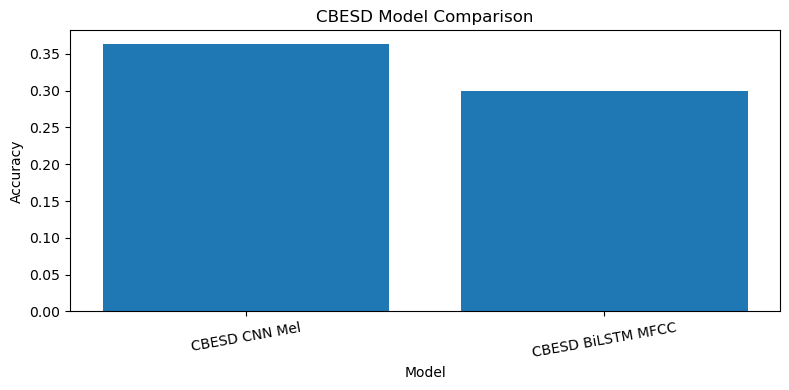

Saved outputs to: /home/ec2-user/SageMaker/cbesd_project/outputs
Saved figures to: /home/ec2-user/SageMaker/cbesd_project/figures


In [23]:
# =========================
# 18. MODEL COMPARISON FOR THESIS
# =========================
if len(train_df):
    result_rows = [cnn_results, lstm_results]
    # if 'w2v_results' in globals():
    #     result_rows.append(w2v_results)

    results_df = pd.DataFrame(result_rows)
    print(results_df)

    plt.figure(figsize=(8, 4))
    plt.bar(results_df["model"], results_df["accuracy"])
    plt.title("CBESD Model Comparison")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cbesd_model_comparison.png", dpi=220)
    plt.show()

    results_df.to_csv(OUT_DIR / "cbesd_model_results.csv", index=False)
    print("Saved outputs to:", OUT_DIR)
    print("Saved figures to:", FIG_DIR)
else:
    print("No results available.")